In [1]:
# import important libraries
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
import joblib

In [2]:
# import dataset
dataset = pd.read_csv("diabetes.csv")
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
# chesk dataset shape
dataset.shape

(768, 9)

In [4]:
# check dataset null values
dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
# check dataset duplicated values
dataset.duplicated().sum()

np.int64(0)

In [6]:
# check dataset description
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# check dataset information
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


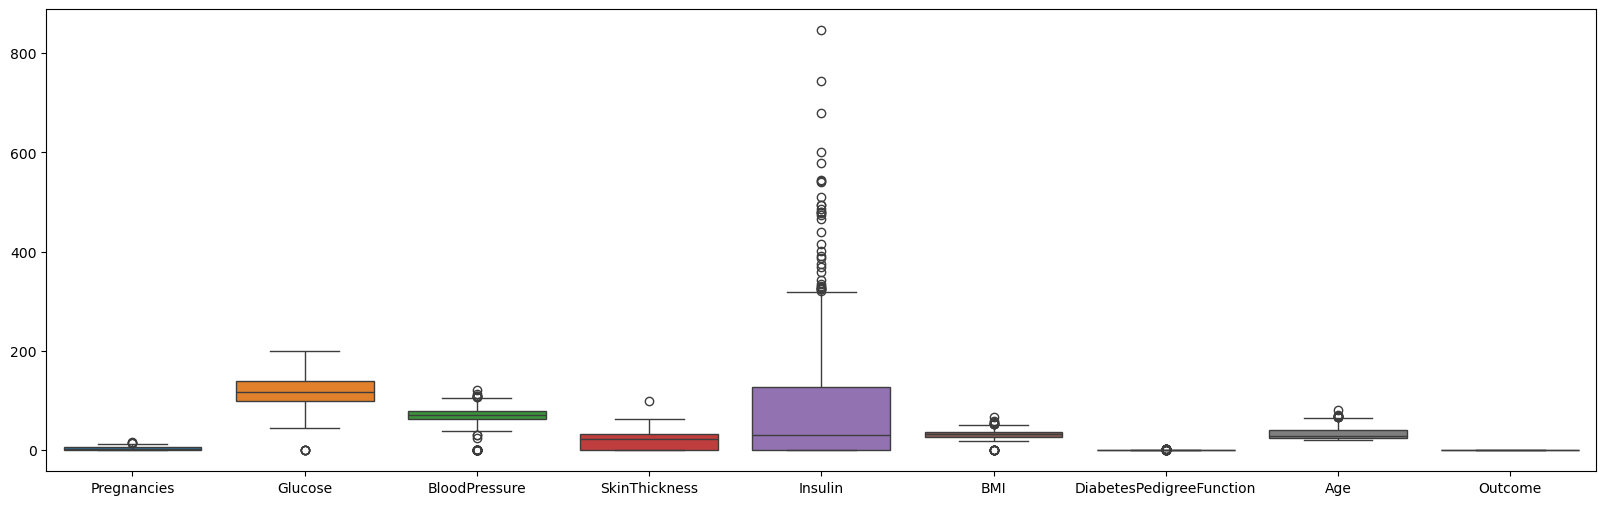

In [8]:
# chech outlier present or not
plt.figure(figsize=(20,6))
sns.boxplot(dataset)
plt.show()

In [9]:
# calculate mean and standard deviation for remove outlier
mn = dataset["Insulin"].mean()
std = dataset["Insulin"].std()
min_range = mn - (3 * std)
max_range = mn + (3 * std)
dataset = dataset[(dataset["Insulin"] > min_range) & (dataset["Insulin"] < max_range)]

In [10]:
# show new dataset
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
# show new dataset shape
dataset.shape

(750, 9)

In [12]:
# sepearate dataset into independent and dependent
x = dataset.iloc[:,:-1]
y = dataset["Outcome"]

In [13]:
# scaled data
sc = StandardScaler()
x_sc = sc.fit_transform(x)
x = pd.DataFrame(x_sc,columns=x.columns)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.632770,0.897257,0.153908,0.932352,-0.770570,0.219023,0.498577,1.433964
1,-0.847509,-1.108391,-0.154045,0.555051,-0.770570,-0.668908,-0.363329,-0.188683
2,1.224881,2.011505,-0.256696,-1.268569,-0.770570,-1.087504,0.639105,-0.103280
3,-0.847509,-0.981048,-0.154045,0.177751,0.286196,-0.478637,-0.937932,-1.042707
4,-1.143565,0.547064,-1.488508,0.932352,1.118119,1.424072,5.685625,-0.017878
...,...,...,...,...,...,...,...,...
745,1.816993,-0.599020,0.359210,1.749837,1.253025,0.130230,-0.925441,2.544197
746,-0.551453,0.069529,0.051257,0.429284,-0.770570,0.624934,-0.397680,-0.530292
747,0.336714,0.037693,0.153908,0.177751,0.488556,-0.719647,-0.694350,-0.274085
748,-0.847509,0.196872,-0.461998,-1.268569,-0.770570,-0.224942,-0.369574,1.177757


In [14]:
# split data into train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
# choose multiple models for best get best model into them
models = {
    "LogisticRegression":LogisticRegression(class_weight={1:3}),
    "SVC":SVC(probability=True),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(n_estimators=100)
}

In [16]:
# train each model
for name,model in models.items():
    model.fit(x_train,y_train)
    print(name,"trained")

LogisticRegression trained
SVC trained
Decision Tree trained
Random Forest trained


In [17]:
# chech each model score
for name,model in models.items():
    print("model:",name)
    y_pred = model.predict(x_test)
    y_pred_proba = model.predict_proba(x_test)[:,1]
    print("train_score:",model.score(x_train,y_train)*100)
    print("test_score:",model.score(x_test,y_test)*100)
    print("accuracy_score:",accuracy_score(y_test,y_pred)*100)
    print("recall_score:",recall_score(y_test,y_pred)*100)
    print("f1_score:",f1_score(y_test,y_pred)*100)
    print("roc_auc_score:",roc_auc_score(y_test,y_pred_proba)*100)
    print()

model: LogisticRegression
train_score: 71.16666666666667
test_score: 71.33333333333334
accuracy_score: 71.33333333333334
recall_score: 89.36170212765957
f1_score: 66.14173228346458
roc_auc_score: 85.72608965089856

model: SVC
train_score: 83.5
test_score: 75.33333333333333
accuracy_score: 75.33333333333333
recall_score: 61.702127659574465
f1_score: 61.05263157894737
roc_auc_score: 81.38814294567239

model: Decision Tree
train_score: 100.0
test_score: 73.33333333333333
accuracy_score: 73.33333333333333
recall_score: 72.3404255319149
f1_score: 62.96296296296296
roc_auc_score: 73.06341664945259

model: Random Forest
train_score: 100.0
test_score: 77.33333333333333
accuracy_score: 77.33333333333333
recall_score: 68.08510638297872
f1_score: 65.3061224489796
roc_auc_score: 83.41251807477794



In [18]:
# predict x_test using best model
y_pred = models["LogisticRegression"].predict(x_test)

In [19]:
# see confusion matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[65, 38],
       [ 5, 42]])

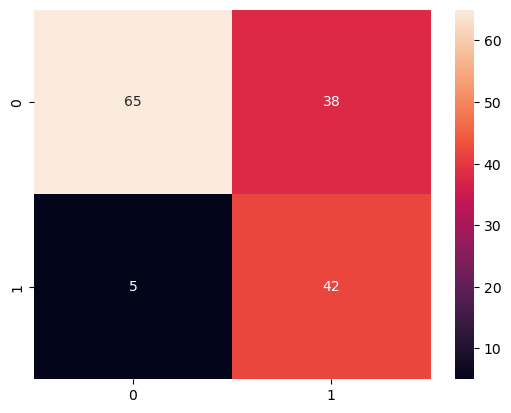

In [20]:
# see confusion matrix using heatmap
sns.heatmap(cm,annot=True)
plt.show()

#convert model into file to use another file

In [21]:
joblib.dump(models["LogisticRegression"],"diabetes.joblib")

['diabetes.joblib']